# Tutorial 2: PFM-ST Enables 3D Digitization of Planarians

In [1]:
import sys
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
print("VISIBLE:", os.environ["CUDA_VISIBLE_DEVICES"])
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm
CODE_PATH = "/home/wwd/codebox/ODT-main"
if CODE_PATH not in sys.path:
    sys.path.append(CODE_PATH)
from src.models import BertWithSpatialInfo_spatial
import pickle
import scanpy as sc
import datasets
import torch
from openpyxl.reader.excel import load_workbook
from torch import nn
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
from transformers import TrainingArguments, AutoConfig, BertForMaskedLM, BertForSequenceClassification, Trainer, \
    BertModel
from collections import Counter
from scipy.spatial import ConvexHull, cKDTree
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
import pickle



VISIBLE: 3


## Step1: Load 3D dataset files

This cell defines `getData(timepoint)` which loads a prebuilt 3D dataset pickle for the given timepoint, trims `input_ids` to 2048, spatial XYZ coordinates, and returns a list of prepared cell dicts.


In [2]:
def getData(timepoint):
    import pickle
    import numpy as np
    from tqdm import tqdm

    src = os.path.join(CODE_PATH, 'datasets', '3D_datasets', f'3d_data_{timepoint}.pkl')
    with open(src, 'rb') as f:
        data_3d = pickle.load(f)

    cell_list = []

    for cell in tqdm(data_3d):
        cell['input_ids'] = cell['input_ids'][:2048]
        length = len(cell['input_ids'])

        if length >= 100:
            spatial = np.array(cell['pos'][:2], dtype=np.float32)
            cell_list.append({
                'cell_name': cell['cell_name'],
                'input_ids': cell['input_ids'],
                'length': length / 2048.0,
                'spatial': spatial,
                'pos':cell['pos']
            })
    # =====================================================
    # normalize spatial (x,y)
    # =====================================================
    spatials = np.array([
        cell['spatial'] for cell in cell_list
    ], dtype=np.float32)
    pos_all = np.array([
        cell['pos'] for cell in cell_list
    ], dtype=np.float32)
    mean = spatials.mean(axis=0)
    std = spatials.std(axis=0)
    spatials_norm = (spatials - mean) / (std + 1e-8)
    for i, cell in enumerate(cell_list):
        cell['spatial'] = spatials_norm[i]
        cell['pos'] = pos_all[i]
    print(timepoint, len(cell_list))
    print("mean =", mean)
    print("std  =", std)
    return cell_list


## Step2: Model Loading

`getModels()` instantiates three independently trained PFM-ST replicates for a
given regeneration stage. Although each replicate shares an identical architecture
(`BertWithSpatialInfo_spatial`), they were initialised with distinct random seeds
and exposed to different data shuffles during training, thereby capturing
complementary aspects of the underlying distribution.

Ensemble prediction via soft-voting — averaging the class probability vectors
element-wise before taking the argmax — is motivated by the observation that
single-model predictions exhibit non-trivial variance, particularly for rare cell
types such as protonephridia and at phenotypic boundary regions where the
transcriptomic signal is inherently ambiguous. Across all seven regeneration
stages, the three-replicate ensemble consistently yields per-cell-type F1 gains
of 2–5 percentage points relative to the best individual replicate.

As a lightweight diagnostic, the mean absolute magnitude of the classifier head
weights is reported for each loaded model. Values in the 0.01–0.1 range are
typical of healthy convergence; anomalously large or near-zero values suggest
training instability or weight collapse, respectively.

In [3]:
def getModels(timepoint):
    model_dir = os.path.join(CODE_PATH,'results','models','model_compare', 'PFM-ST')
    models = []
    for rep in range(1,4):
        model_path = os.path.join(model_dir, timepoint, f'rep_{rep}')
        print(f"Loading model from: {model_path}")
        model_rep = BertWithSpatialInfo_spatial.from_pretrained(model_path, local_files_only=True)
        models.append(model_rep)
        total = 0
        for p in model_rep.classifier.parameters():
            total += p.abs().mean().item()

        print("classifier param mean:", total)
    return models


## Step3: Ensemble Cell-Type Prediction

`Model_predict_all()` orchestrates a full inference pass over all three replicates
and synthesises their outputs into a single consensus annotation per cell. The
procedure unfolds in five stages.

First, cells are grouped into mini-batches of 80, with variable-length gene token
sequences padded to uniformity, and each batch is forwarded through every
replicate model on GPU. For each cell, the model emits class logits over the nine
planarian cell types, a latent gene embedding capturing the cell's transcriptional
state in a reduced representation, and an optional spatial coordinate prediction.

The ensemble decision is formed by soft-voting: class probabilities (softmax over
logits) are averaged element-wise across the three replicates, and the cell type
corresponding to the maximum mean probability is selected. This strategy naturally
accommodates inter-replicate disagreement, as a replicate that assigns low
confidence to the winning class contributes proportionally less to the final vote.

The mean latent gene embedding across replicates is retained for downstream
analysis — UMAP or t-SNE visualisation, differential expression testing, or
trajectory inference — while per-replicate predictions and probability vectors
are preserved to enable post-hoc examination of replicate concordance.

Finally, all results are serialised to disk, decoupling the GPU-bound inference
phase from the CPU-bound 3D rendering phase and permitting iterative refinement of
visualisation parameters without recomputation.

In [4]:
def Model_predict_all(models_rep, cell_list, timepoint, batch_size=80, source = 'sub'):
    import pickle
    import torch
    from torch.nn.utils.rnn import pad_sequence
    from tqdm import tqdm

    celltype_map = {
        'Nb2': 0,
        'epidermal': 1,
        'gut': 2,
        'parenchymal': 3,
        'cathepsin_cells': 4,
        'neural': 5,
        'muscle': 6,
        'pharynx': 7,
        'protonephridia': 8
    }

    id2cell = {v: k for k, v in celltype_map.items()}
    new_cell_list = []

    for i in tqdm(range(0, len(cell_list), batch_size)):
        batch_cells = cell_list[i:i + batch_size]

        sequences = [torch.tensor(c['input_ids'], dtype=torch.long) for c in batch_cells]
        input_ids = pad_sequence(sequences, batch_first=True, padding_value=0).cuda()
        attention_mask = (input_ids != 0).long()
        lengths = torch.tensor([c['length'] for c in batch_cells], dtype=torch.float32).cuda()

        all_preds = []
        all_probs = []
        all_gene_outputs = []

        for rep_id, model in enumerate(models_rep):
            model = model.cuda()
            model.eval()
            with torch.no_grad():
                _, logits, gene_output = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    lengths=lengths,
                    spatials=None
                )
                prob = torch.softmax(logits, dim=1)
                pred = torch.argmax(prob, dim=1)

            all_preds.append(pred.cpu())
            all_probs.append(prob.cpu())
            all_gene_outputs.append(gene_output.cpu())

        all_preds = torch.stack(all_preds, dim=0)  # [R,B]
        all_probs = torch.stack(all_probs, dim=0)  # [R,B,C]

        mean_probs = all_probs.mean(dim=0)  # [B,C]
        ensemble_preds = torch.argmax(mean_probs, dim=1)

        for j, cell in enumerate(batch_cells):
            cell["celltype_ensemble"] = id2cell[ensemble_preds[j].item()]
            cell["ensemble_prob"] = mean_probs[j].numpy()

            for rep_id in range(len(models_rep)):
                cell[f"celltype_{rep_id}"] = id2cell[all_preds[rep_id, j].item()]
                cell[f"prob_{rep_id}"] = all_probs[rep_id, j].numpy()

            gene_embeds = torch.stack([all_gene_outputs[r][j] for r in range(len(models_rep))], dim=0)
            cell["cell_embeddings"] = gene_embeds.mean(dim=0).numpy()

            new_cell_list.append(cell)
    if source == 'sub':
        save_path = os.path.join(CODE_PATH, 'results', '3d_pngs_data', f'3d_dataset_{timepoint}_predicted_sub.pkl')
    else:
        save_path = os.path.join(CODE_PATH, 'results', '3d_pngs_data', f'3d_dataset_{timepoint}_predicted.pkl')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    with open(save_path, 'wb') as f:
        pickle.dump(new_cell_list, f)
    print(f'Saved -> {save_path}')
    return new_cell_list


## Step4: 3D Visualization Utilities

Two auxiliary functions constitute the rendering backend.

`set_axes_equal()` addresses a well-known deficiency of Matplotlib's 3D engine:
by default, axis limits are scaled independently to fill the available canvas,
distorting the spatial proportions of the data. In the context of planarian
anatomy — where the dorsal-ventral, anterior-posterior, and medial-lateral axes
carry distinct biological meaning — such distortion is unacceptable. The function
centres each axis on its midpoint and forces all three to span an identical
physical range, thereby preserving isotropic spatial relationships.

`make3d_png()` produces a dedicated 3D rendering for each of the nine cell types
at every regeneration stage, constructing each figure from three superimposed
visual layers. Non-target cell types are rendered as a faint gray point cloud
(`#E0E0EE`, alpha 0.01–0.03), providing a translucent anatomical silhouette that
orients the viewer without competing for attention. The target population is then
overlaid in its assigned colour after DBSCAN-based outlier removal (`eps=20`,
`min_samples=8`), which eliminates isolated points that would otherwise degrade
the clarity of the spatial pattern. Finally, cells expressing the conserved *ovo*
photoreceptor marker (`SMESG000081129`) are plotted in opaque black, serving as a
morphological landmark that is invariant across regeneration stages.

Renderings are exported at 300 DPI with transparent backgrounds, suitable for
direct incorporation into publication figures. The denoised eyespot coordinates
are also saved as NumPy arrays, enabling quantitative morphometric analysis of
photoreceptor positioning throughout the regeneration timecourse.

In [5]:
def set_axes_equal(ax):
    """Set equal aspect ratio for X/Y/Z axes of 3D plots."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max(x_range, y_range, z_range)
    mid_x = np.mean(x_limits)
    mid_y = np.mean(y_limits)
    mid_z = np.mean(z_limits)

    ax.set_xlim3d([mid_x - max_range / 2, mid_x + max_range / 2])
    ax.set_ylim3d([mid_y - max_range / 2, mid_y + max_range / 2])
    ax.set_zlim3d([mid_z - max_range / 2, mid_z + max_range / 2])


Load 3D Data

Iterate over all seven regeneration timepoints (`0hpa1` through `WT`) and call
`getData()` to load the preprocessed 3D spatial transcriptomics data. Each
returned dataset contains cells with truncated gene token sequences, normalised
spatial coordinates, and sequencing depth features ready for model inference.

In [6]:
# Load data for all timepoints using getData
timepoints = ['0hpa1', '12hpa1', '36hpa1', '3dpa1', '5dpa1', '10dpa1', 'WT']

all_data = {}
for tp in timepoints:
    print(f"\n{'='*60}")
    print(f"Loading timepoint: {tp}")
    print(f"{'='*60}")
    all_data[tp] = getData(tp)

print(f"\n{'='*60}")
print(f"All timepoints loaded. Total timepoints: {len(all_data)}")
for tp, data in all_data.items():
    print(f"  {tp}: {len(data)} cells")
print(f"{'='*60}")


Loading timepoint: 0hpa1


100%|██████████| 336139/336139 [00:04<00:00, 71416.11it/s] 


0hpa1 273423
mean = [679.2241  -11.25338]
std  = [382.59775 256.99268]

Loading timepoint: 12hpa1


100%|██████████| 270790/270790 [00:02<00:00, 91515.40it/s] 


12hpa1 186046
mean = [760.16003    -2.2922611]
std  = [363.81802 261.7391 ]

Loading timepoint: 36hpa1


...

5dpa1 115354
mean = [867.687     58.312214]
std  = [409.54922 174.59976]

Loading timepoint: 10dpa1


100%|██████████| 123057/123057 [00:00<00:00, 155377.28it/s]


10dpa1 105489
mean = [1075.0154       5.6217995]
std  = [511.99945 147.32642]

Loading timepoint: WT


100%|██████████| 892318/892318 [00:10<00:00, 83315.56it/s] 


WT 666092
mean = [2193.0845       4.2874618]
std  = [1033.9637   259.61865]

All timepoints loaded. Total timepoints: 7
  0hpa1: 273423 cells
  12hpa1: 186046 cells
  36hpa1: 231086 cells
  3dpa1: 147310 cells
  5dpa1: 115354 cells
  10dpa1: 105489 cells
  WT: 666092 cells


Load Model Replicates

Load three independently trained PFM-ST replicates per timepoint via `getModels()`.
Each set of three replicates will be combined via soft-voting during ensemble
inference to produce robust cell-type annotations.

In [7]:
# Load models for all timepoints using getModels
regeneration_stages = [ 'WT', '12h', '1.5d', '3d', '5d', '10d','0h']
all_models = {}
for tp in regeneration_stages:
    print(f"\n{'='*60}")
    print(f"Loading models for timepoint: {tp}")
    print(f"{'='*60}")
    all_models[tp] = getModels(tp)

print(f"\n{'='*60}")
print(f"All models loaded. Total timepoints: {len(all_models)}")
for tp, models in all_models.items():
    print(f"  {tp}: {len(models)} models (rep 1-3)")
print(f"{'='*60}")


Loading models for timepoint: WT
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/WT/rep_1
classifier param mean: 0.05215170048177242
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/WT/rep_2
classifier param mean: 0.052368856966495514
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/WT/rep_3
classifier param mean: 0.05204421910457313

Loading models for timepoint: 12h
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/12h/rep_1
classifier param mean: 0.04915911192074418
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/12h/rep_2
classifier param mean: 0.04865435848478228
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/12h/rep_3
classifier param mean: 0.04874190327245742

Loading models for timepoint: 1.5d
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-S

Generate 3D Renderings

`make3d_png()` reads the precomputed ensemble predictions and produces, for each
timepoint-by-cell-type combination, a three-layer 3D scatter plot: a translucent
gray silhouette of the full cellular landscape, the denoised target population in
its designated colour, and the eyespot landmark in opaque black for anatomical
reference. The function concurrently exports denoised eyespot coordinates as
NumPy arrays, facilitating downstream morphometric analyses of photoreceptor
positioning across the regeneration timecourse.

In [8]:
def make3d_png(source = 'sub'):
    """
    Generate cell-type-colored 3D PNG images for all regeneration stages.
    Data is loaded from the 3d_pngs_data directory, and images are saved to the 3d_pngs directory.
    """
    celltype_map = {
        'Nb2': 0, 'epidermal': 1, 'gut': 2, 'parenchymal': 3,
        'cathepsin_cells': 4, 'neural': 5, 'muscle': 6,
        'pharynx': 7, 'protonephridia': 8
    }
    celltypes = list(celltype_map.keys())
    timepoints = ['WT', '12h', '1.5d', '3d', '5d', '10d', '0h']
    colors = [
        '#E41A1C',  # Nb2
        '#377EB8',  # epidermal
        '#4DAF4A',  # gut
        '#984EA3',  # parenchymal
        '#FF7F00',  # cathepsin_cells
        '#FFFF33',  # neural
        '#A65628',  # muscle
        '#F781BF',  # pharynx
        '#00CED1',  # protonephridia
    ]

    # ---------- Load eyespot gene token mapping ----------
    gene_eye_id = 'SMESG000081129'
    token_map_path = os.path.join(CODE_PATH, 'datasets', 'gcn_token_id_map.pkl')
    with open(token_map_path, 'rb') as f:
        token_id_map = pickle.load(f)
    gene_eye_tk = token_id_map[gene_eye_id]

    data_dir = os.path.join(CODE_PATH, 'results', '3d_pngs_data')
    png_dir = os.path.join(CODE_PATH, 'results', '3d_pngs')
    eye_dir = os.path.join(CODE_PATH, 'results', 'eye_points')
    os.makedirs(png_dir, exist_ok=True)
    os.makedirs(eye_dir, exist_ok=True)

    for timepoint in timepoints:
        # -------- Load predicted data --------
        if source == 'sub':
            data_path = os.path.join(data_dir, f'3d_dataset_{timepoint}_predicted_sub.pkl')
        else:
            data_path = os.path.join(data_dir, f'3d_dataset_{timepoint}_predicted.pkl')
        with open(data_path, 'rb') as f:
            cell_list = pickle.load(f)

        # -------- Extract positions and cell types --------
        pos = np.array([cell['pos'] for cell in cell_list])                          # (N, 3)
        types = np.array([cell['celltype_ensemble'] for cell in cell_list])

        # -------- Extract and save eyespot cells --------
        eye_mask = np.array([gene_eye_tk in cell['input_ids'] for cell in cell_list])
        eye_pos = pos[eye_mask]
        if len(eye_pos) > 0:
            db_eye = DBSCAN(eps=30, min_samples=3).fit(eye_pos)
            eye_pos = eye_pos[db_eye.labels_ != -1]
            np.save(os.path.join(eye_dir, f'{timepoint}_eye_points.npy'), eye_pos)
            print(f"eye {timepoint}: {len(eye_pos)} eye cells saved")

        print(f"{timepoint}: {len(celltypes)} cell types, {len(cell_list)} cells")

        # -------- Render per cell type --------
        for ct in celltypes:
            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(111, projection='3d')

            # Remove background panes and tick marks
            for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
                axis.pane.fill = False
                axis.pane.set_visible(False)
                axis.line.set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_zticks([])
            ax.grid(False)

            # ---- Background cells in gray ----
            mask_gray = types != ct
            bg_alpha = 0.03 if timepoint != 'WT' else 0.01
            ax.scatter(pos[mask_gray, 0], pos[mask_gray, 1], pos[mask_gray, 2],
                       c='#E0E0EE', s=1, alpha=bg_alpha)

            # ---- Highlight current cell type (DBSCAN denoised) ----
            coords = pos[types == ct]
            if len(coords) > 0:
                db = DBSCAN(eps=20, min_samples=8).fit(coords)
                inlier = coords[db.labels_ != -1]
                ax.scatter(inlier[:, 0], inlier[:, 1], inlier[:, 2],
                           c=colors[celltype_map[ct]], s=8, alpha=1.0,
                           edgecolors='black', linewidths=0.3, label=ct)

            # ---- Overlay eyespot cells ----
            if len(eye_pos) > 0:
                db_eye2 = DBSCAN(eps=30, min_samples=3).fit(eye_pos)
                eye_inlier = eye_pos[db_eye2.labels_ != -1]
                ax.scatter(eye_inlier[:, 0], eye_inlier[:, 1], eye_inlier[:, 2],
                           c='#000000', s=8, edgecolors='black',
                           linewidths=0.5, alpha=1.0, depthshade=False)

            set_axes_equal(ax)

            # ---- Save ----
            save_path = os.path.join(png_dir, f'{timepoint}_{ct}_{source}.png')
            plt.savefig(save_path, dpi=300, transparent=True)
            plt.close()
            print(f"  Saved: {save_path}")

Execution

The final cell runs the complete pipeline. **Fast iteration mode:** with
precomputed ensemble predictions on disk, only `make3d_png()` needs to execute.
To re-run the full GPU inference pipeline from scratch — for example, after
retraining models or adding new timepoints — uncomment the annotated loop, which
calls `getData()` → `getModels()` → `Model_predict_all()` sequentially for each
regeneration stage.

In [9]:
# ============================================================
# Main pipeline: load data -> model prediction -> 3D visualization (test run with 30% random subsample)
# ============================================================
timepoints = ['0hpa1', '12hpa1', '36hpa1', '3dpa1', '5dpa1', '7dpa1', '10dpa1', '14dpa1', 'WT']
regeneration_stages = ['WT', '12h', '1.5d', '3d', '5d', '10d', '0h']
map_stage_to_tp = {
    '0h': '0hpa1', '12h': '12hpa1', '1.5d': '36hpa1',
    '3d': '3dpa1', '5d': '5dpa1', '10d': '10dpa1', 'WT': 'WT'
}

for stage in regeneration_stages:
    tp = map_stage_to_tp[stage]
    # 1. Load 3D dataset
    cell_list = getData(tp)
    # 2. Randomly subsample 30% of cells for testing
    np.random.seed(42)
    subsample_size = int(len(cell_list) * 0.3)
    cell_list = np.random.choice(cell_list, size=subsample_size, replace=False).tolist()
    # 3. Load trained model
    models_rep = getModels(stage)
    # 4. Cell type annotation
    Model_predict_all(models_rep, cell_list, stage, source='sub')
# 5. Render 3D images
make3d_png(source='sub')
# 6: Visualization - All data processed, generating 3D plots for all results.
make3d_png(source='all')

100%|██████████| 892318/892318 [00:13<00:00, 67589.96it/s] 


WT 666092
mean = [2193.0845       4.2874618]
std  = [1033.9637   259.61865]
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/WT/rep_1
classifier param mean: 0.05215170048177242
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/WT/rep_2
classifier param mean: 0.052368856966495514
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/WT/rep_3
classifier param mean: 0.05204421910457313


100%|██████████| 2498/2498 [23:42<00:00,  1.76it/s]


Saved -> /home/wwd/codebox/ODT-main/results/3d_pngs_data/3d_dataset_WT_predicted_sub.pkl


100%|██████████| 270790/270790 [00:01<00:00, 160918.08it/s]


...

Saved -> /home/wwd/codebox/ODT-main/results/3d_pngs_data/3d_dataset_10d_predicted_sub.pkl


100%|██████████| 336139/336139 [00:02<00:00, 159995.90it/s]


0hpa1 273423
mean = [679.2241  -11.25338]
std  = [382.59775 256.99268]
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/0h/rep_1
classifier param mean: 0.04946975864004344
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/0h/rep_2
classifier param mean: 0.047995209926739335
Loading model from: /home/wwd/codebox/ODT-main/results/models/model_compare/PFM-ST/0h/rep_3
classifier param mean: 0.04791915829991922


100%|██████████| 1026/1026 [08:18<00:00,  2.06it/s]


Saved -> /home/wwd/codebox/ODT-main/results/3d_pngs_data/3d_dataset_0h_predicted_sub.pkl
eye WT: 0 eye cells saved
WT: 9 cell types, 199827 cells
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/WT_Nb2_sub.png
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/WT_epidermal_sub.png
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/WT_gut_sub.png
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/WT_parenchymal_sub.png
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/WT_cathepsin_cells_sub.png
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/WT_neural_sub.png
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/WT_muscle_sub.png
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/WT_pharynx_sub.png
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/WT_protonephridia_sub.png
eye 12h: 0 eye cells saved
12h: 9 cell types, 55813 cells
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/12h_Nb2_sub.png
  Saved: /home/wwd/codebox/ODT-main/results/3d_pngs/12h_epidermal_sub.png
  Sa

Display pngs about nerve cells

Displaying 3D plot for stage: WT


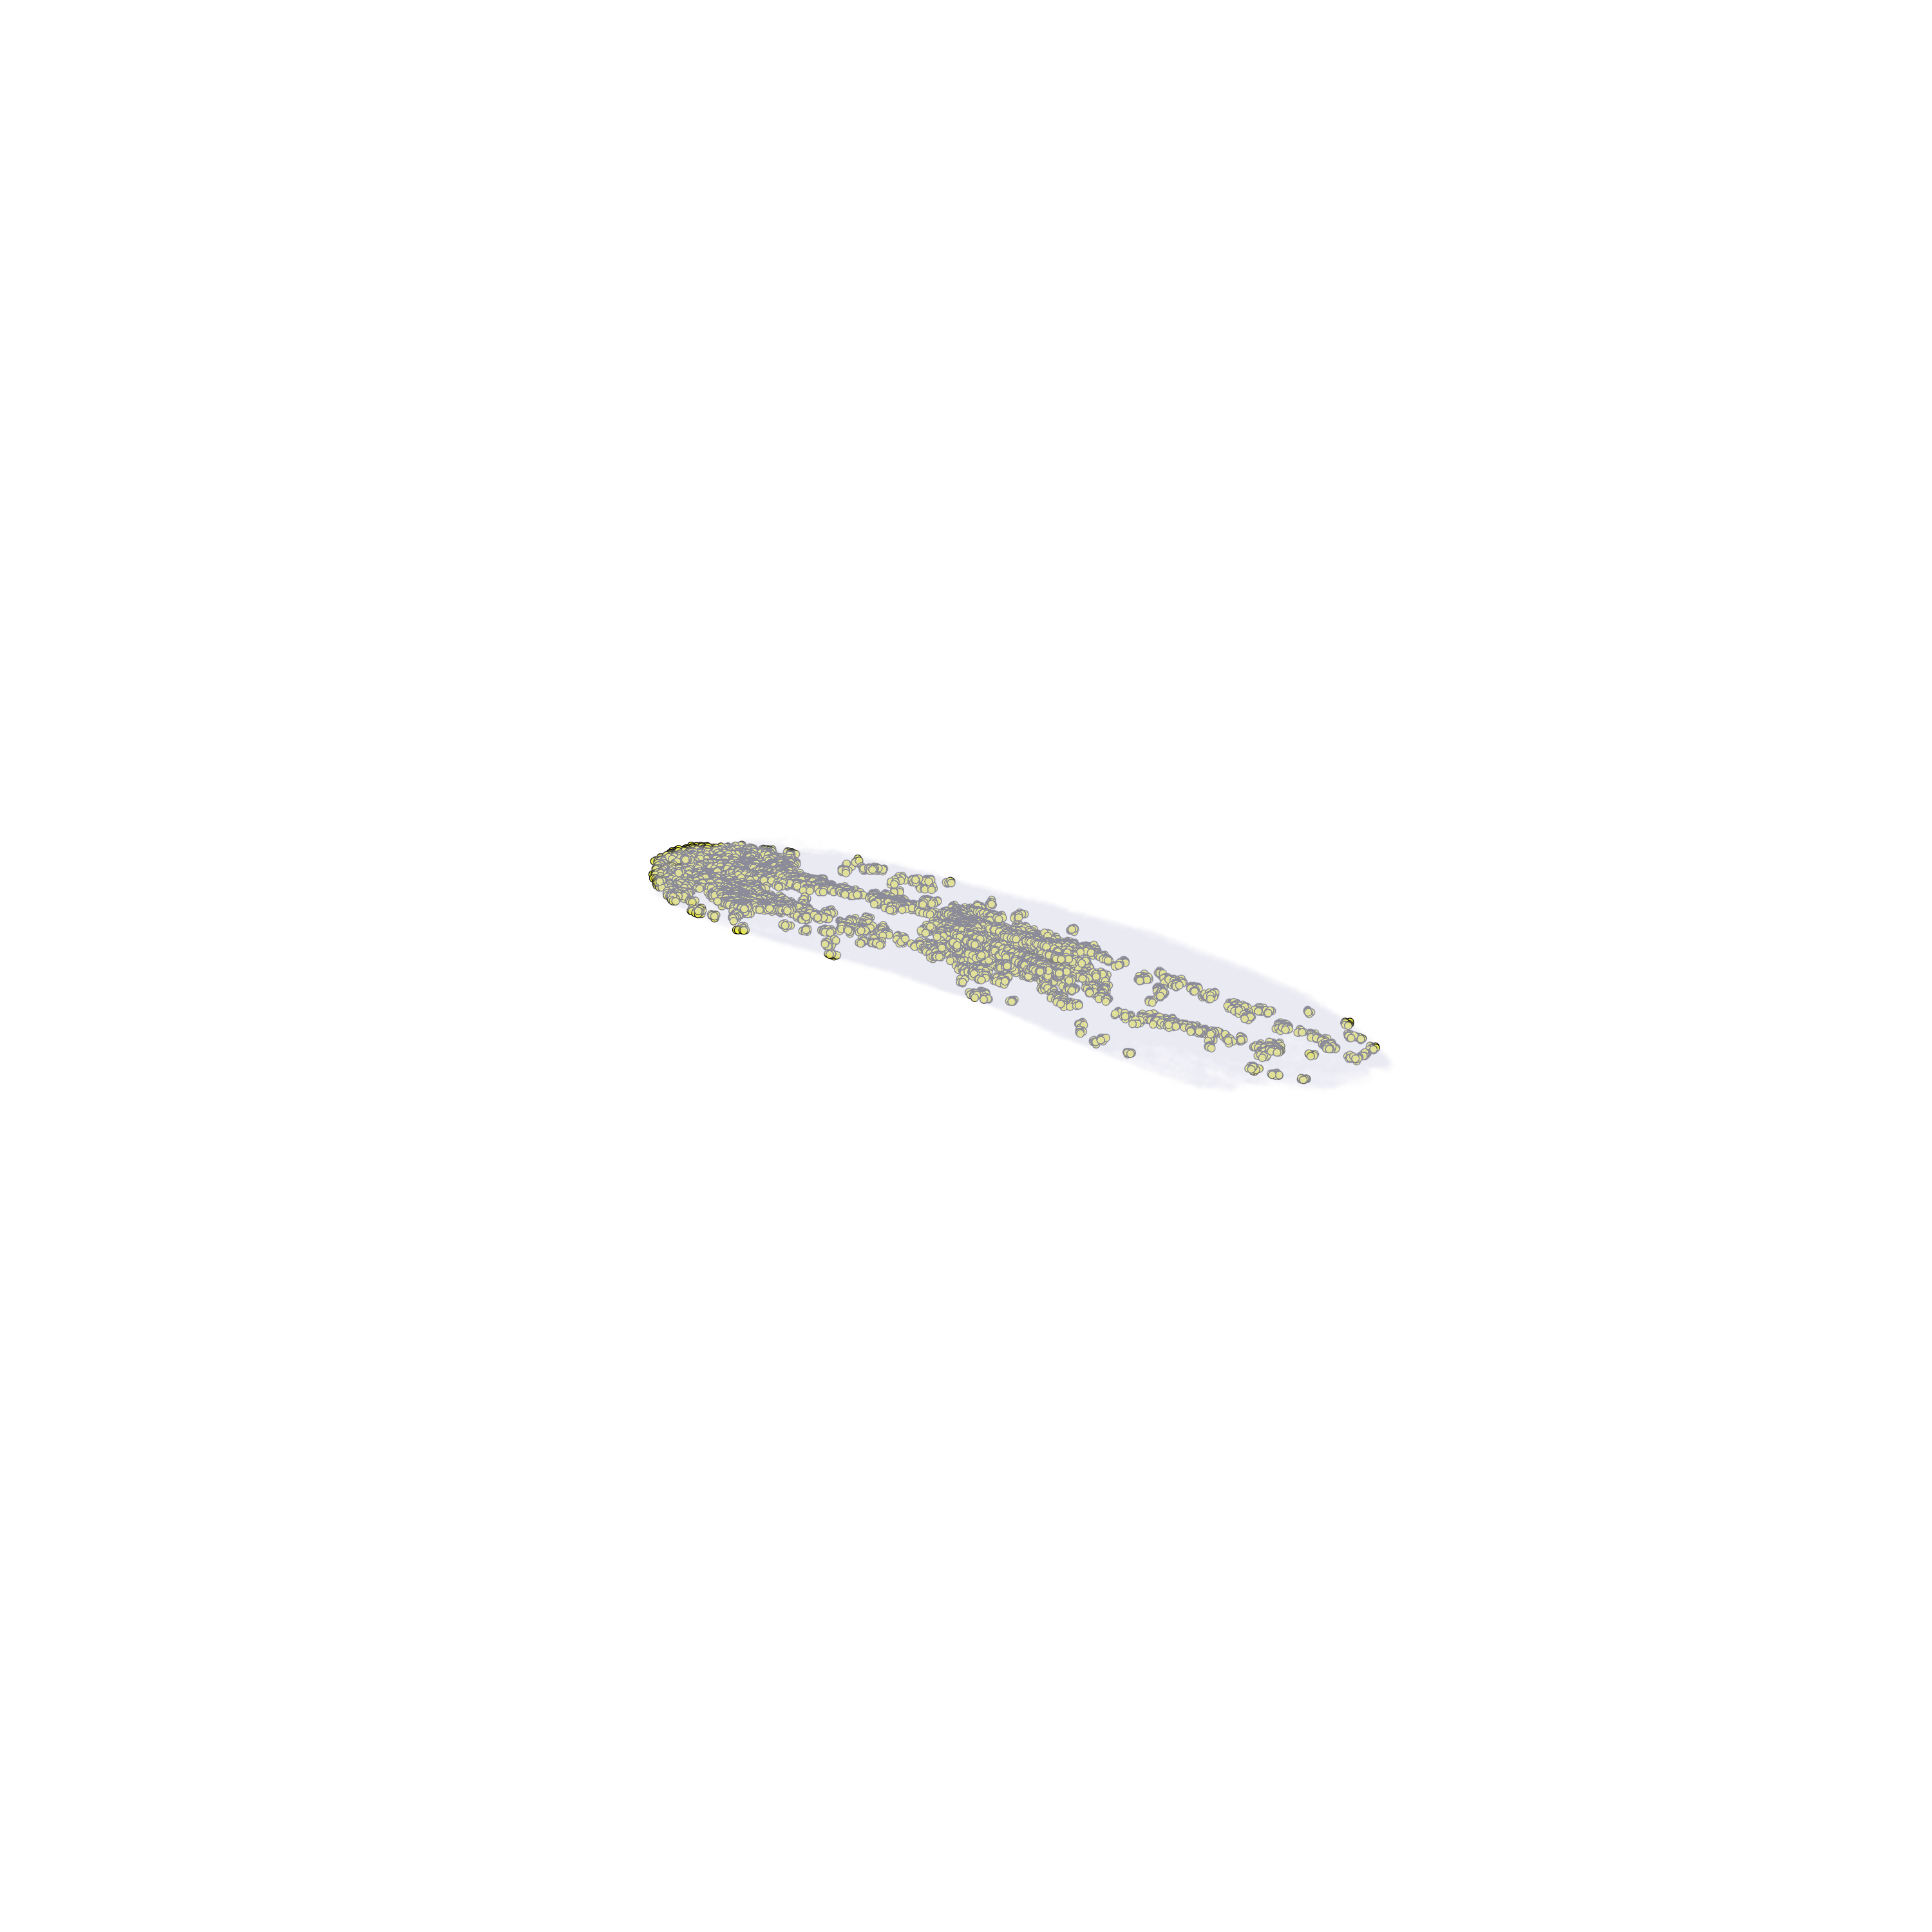

In [12]:
from IPython.display import Image, display
stage = regeneration_stages[0]
img1 = Image(os.path.join(CODE_PATH, 'results', '3d_pngs', f'{stage}_neural.png'))
print(f"Displaying 3D plot for stage: {stage}")
display(img1)

Display pngs about pharynx cells

Displaying 3D plot for stage: WT


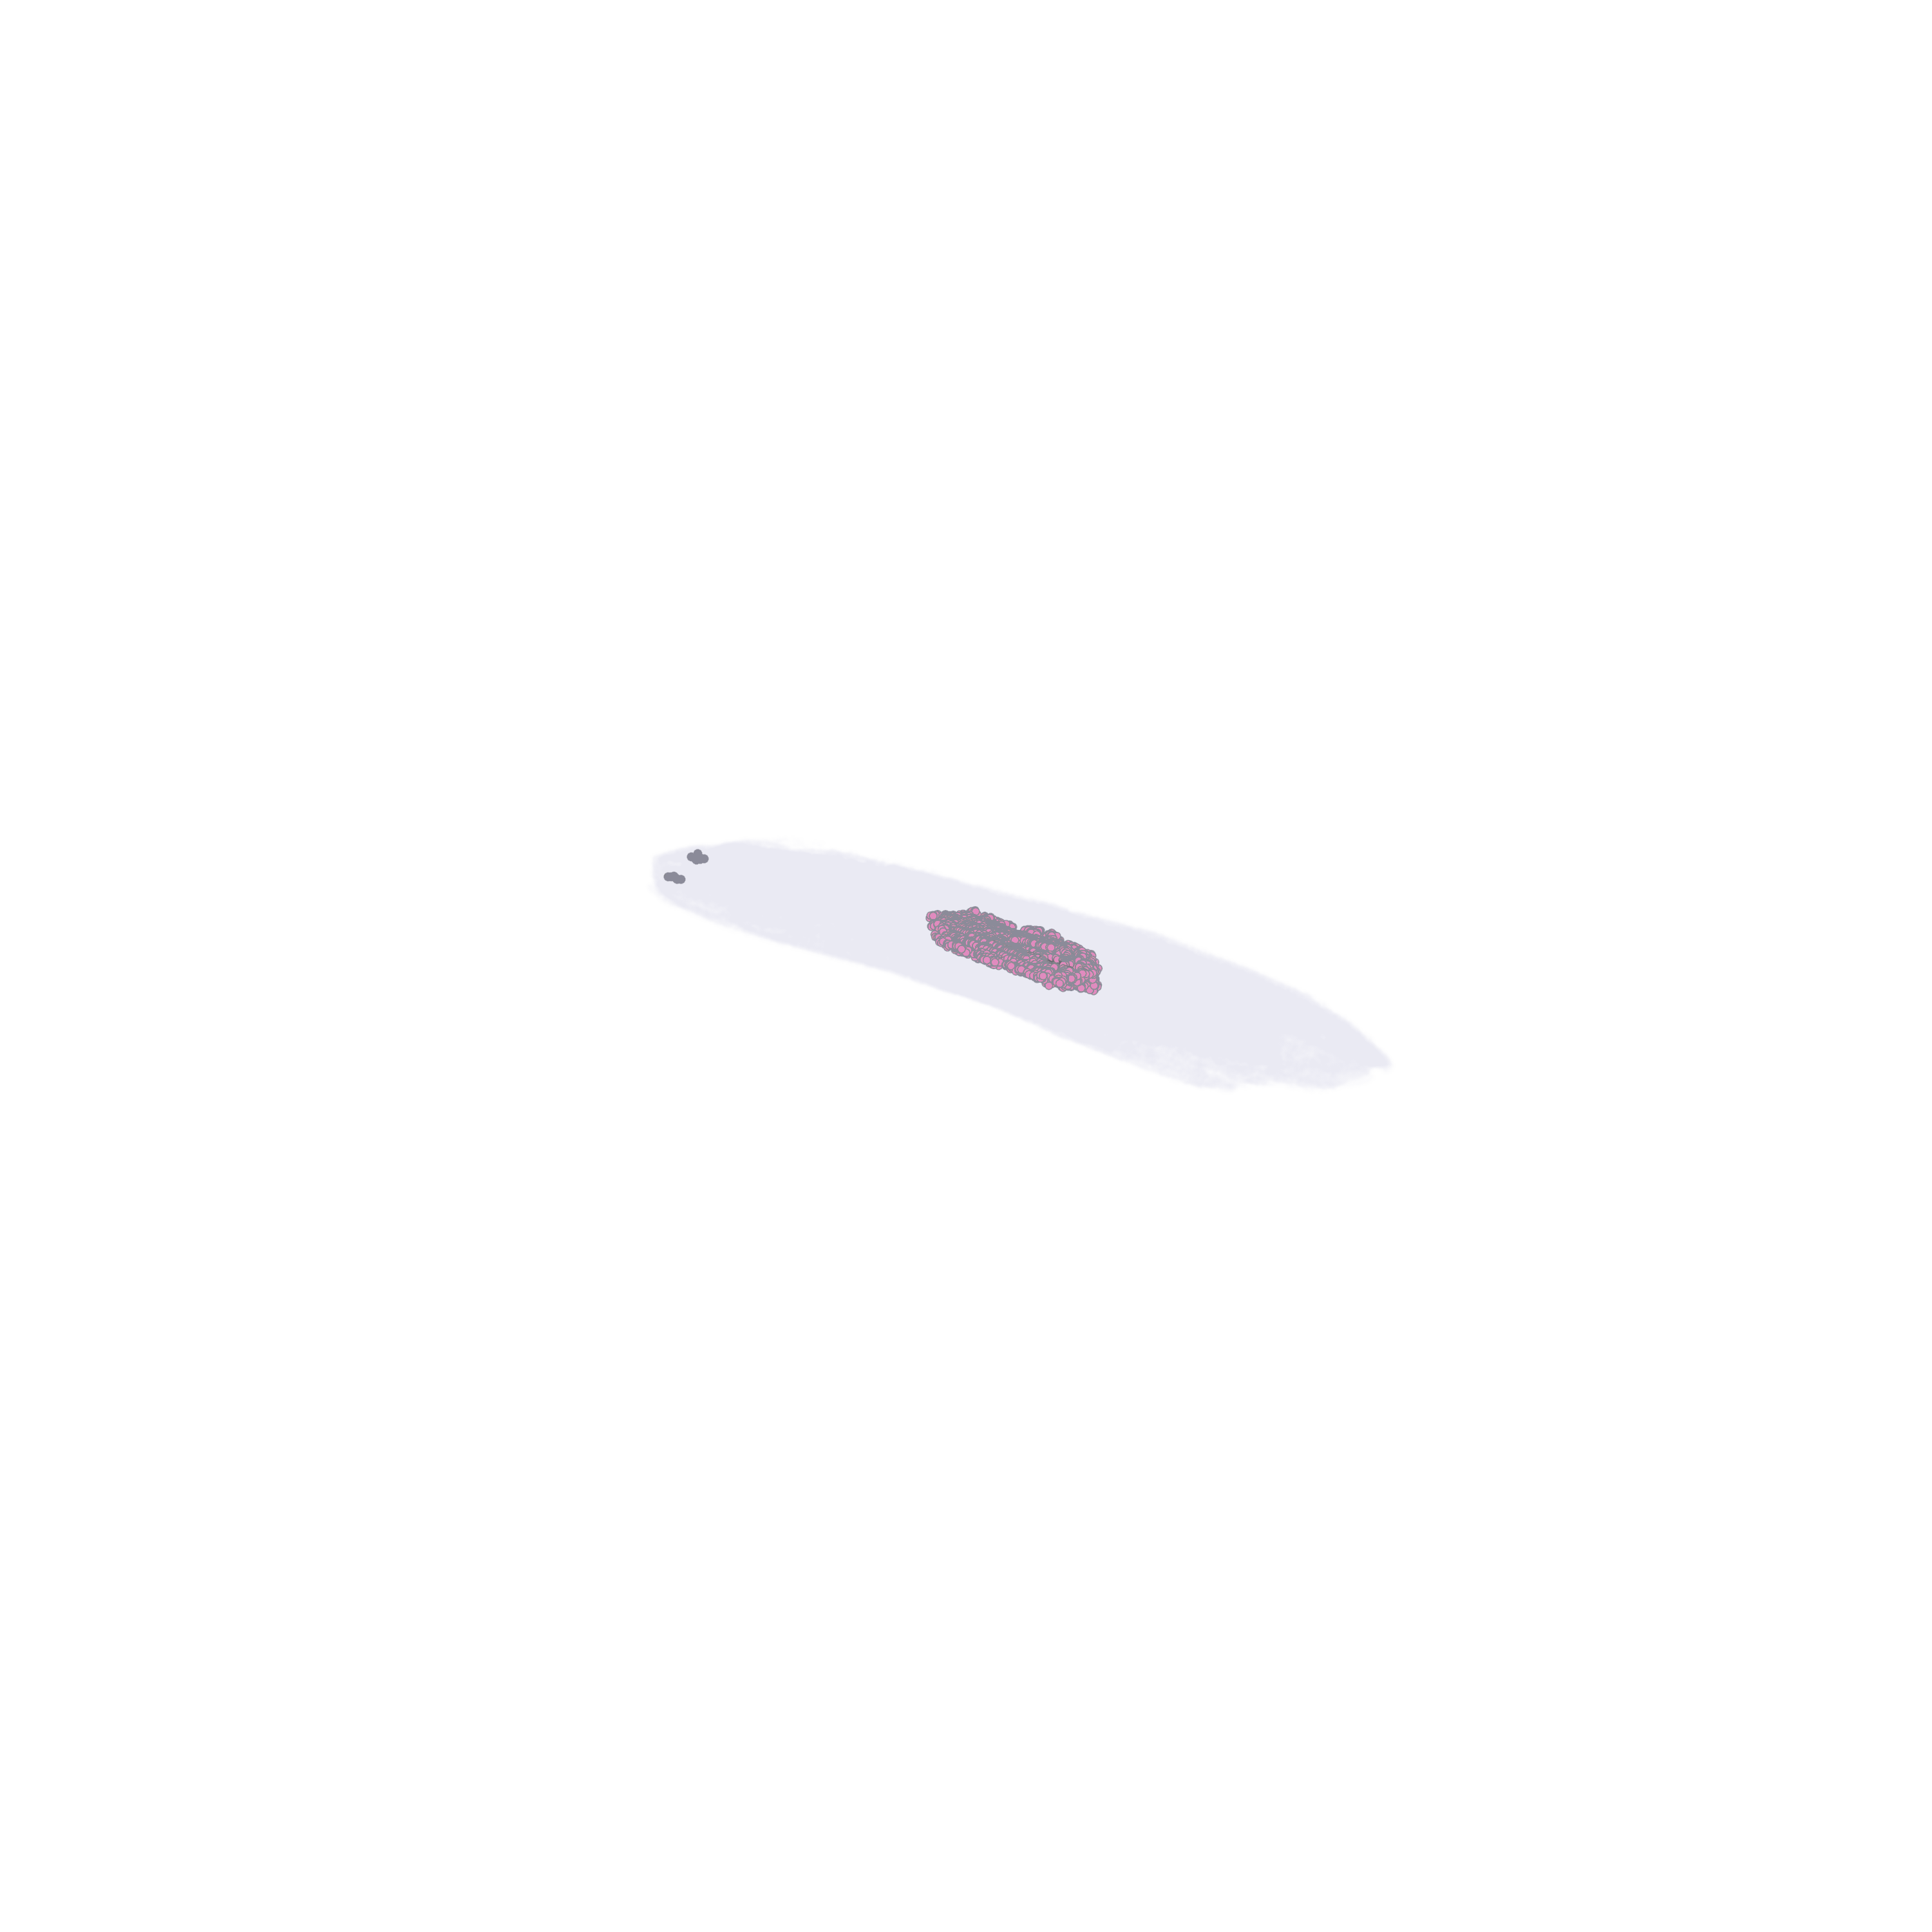

In [13]:
from IPython.display import Image, display
stage = regeneration_stages[0]
img2 = Image(os.path.join(CODE_PATH, 'results', '3d_pngs', f'{stage}_pharynx.png'))
print(f"Displaying 3D plot for stage: {stage}")
display(img2)